## Rutas e imports

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd

from src.portfolio import (
    simulate_portfolio,
    calculate_portfolio_metrics,
    get_logistic,
    get_rf,
    get_xgb
)

## Cargar dataset

In [2]:
df = pd.read_csv("../data/processed/panel_dataset_v1.csv")

df["date"] = pd.to_datetime(df["date"])

print(df.shape)
print(df["date"].min(), df["date"].max())
print(df["target"].value_counts())

(3440, 15)
2010-08-01 00:00:00 2024-11-01 00:00:00
target
1    1914
0    1526
Name: count, dtype: int64


## Definir variables

In [3]:
market_features = [
    "return_lag1",
    "ret_3m",
    "ret_6m",
    "vol_3m",
    "vol_6m",
    "excess_return",
    "rank_ret_3m"
]

market_macro_features = market_features + [
    "inflation",
    "interest_rate",
    "unemployment"
]

## Función auxiliar para ejecutar modelos

In [4]:
def run_portfolio_test(model_name, model_func, features, feature_set):
    returns = simulate_portfolio(
        df=df,
        model_func=model_func,
        features=features,
        top_pct=0.2,
        start_test_year=2015
    )
    
    metrics = calculate_portfolio_metrics(returns)
    
    result = {
        "model": model_name,
        "feature_set": feature_set,
        "cumulative_return": metrics["cumulative_return"],
        "annualized_volatility": metrics["annualized_volatility"],
        "sharpe_ratio": metrics["sharpe_ratio"],
        "max_drawdown": metrics["max_drawdown"],
    }
    
    return returns, result

## Ejecutar todos los modelos

In [5]:
results = []
returns_dict = {}

experiments = [
    ("Logistic Regression", get_logistic, market_features, "market"),
    ("Logistic Regression", get_logistic, market_macro_features, "market_macro"),
    ("Random Forest", get_rf, market_features, "market"),
    ("Random Forest", get_rf, market_macro_features, "market_macro"),
    ("XGBoost", get_xgb, market_features, "market"),
    ("XGBoost", get_xgb, market_macro_features, "market_macro"),
]

for model_name, model_func, features, feature_set in experiments:
    returns, result = run_portfolio_test(
        model_name=model_name,
        model_func=model_func,
        features=features,
        feature_set=feature_set
    )
    
    results.append(result)
    returns_dict[(model_name, feature_set)] = returns

results_df = pd.DataFrame(results)

results_df

,model,feature_set,cumulative_return,annualized_volatility,sharpe_ratio,max_drawdown
0,Logistic Regression,market,2.735891,0.245959,0.671763,-0.427813
1,Logistic Regression,market_macro,3.170766,0.236318,0.735865,-0.398663
2,Random Forest,market,2.114530,0.213595,0.647300,-0.284994
3,Random Forest,market_macro,3.141001,0.209507,0.796387,-0.276237
4,XGBoost,market,3.364033,0.217990,0.796111,-0.284220
5,XGBoost,market_macro,3.428824,0.214670,0.812161,-0.281973


## Guardar resultados

In [6]:
import os

os.makedirs("../results/portfolio", exist_ok=True)

results_df.to_csv(
    "../results/portfolio/portfolio_metrics.csv",
    index=False
)

results_df

,model,feature_set,cumulative_return,annualized_volatility,sharpe_ratio,max_drawdown
0,Logistic Regression,market,2.735891,0.245959,0.671763,-0.427813
1,Logistic Regression,market_macro,3.170766,0.236318,0.735865,-0.398663
2,Random Forest,market,2.114530,0.213595,0.647300,-0.284994
3,Random Forest,market_macro,3.141001,0.209507,0.796387,-0.276237
4,XGBoost,market,3.364033,0.217990,0.796111,-0.284220
5,XGBoost,market_macro,3.428824,0.214670,0.812161,-0.281973


## Curvas acumuladas

In [7]:
cumulative_curves = {}

for key, returns in returns_dict.items():
    cumulative_curves[key] = (1 + returns).cumprod()

cumulative_df = pd.DataFrame(cumulative_curves)

cumulative_df.head()

Logistic Regression              Random Forest               \
                        market market_macro        market market_macro   
date                                                                     
2015-01-01            1.122558     1.122558      1.103030     1.103030   
2015-02-01            1.171079     1.171079      1.178455     1.179908   
2015-03-01            1.163633     1.163633      1.176450     1.177901   
2015-04-01            1.165585     1.165585      1.177464     1.159908   
2015-05-01            1.142722     1.142722      1.158413     1.147629   

             XGBoost               
              market market_macro  
date                               
2015-01-01  1.103030     1.073584  
2015-02-01  1.150779     1.128994  
2015-03-01  1.159817     1.158128  
2015-04-01  1.128726     1.126323  
2015-05-01  1.110464     1.095174

## Guardar curvas acumuladas

In [8]:
cumulative_df.to_csv(
    "../results/portfolio/cumulative_returns.csv"
)

cumulative_df.tail()

Logistic Regression              Random Forest               \
                        market market_macro        market market_macro   
date                                                                     
2024-06-01            4.086861     4.562591      3.303072     4.059752   
2024-07-01            4.080431     4.555412      3.298896     4.161080   
2024-08-01            3.975404     4.438160      3.220856     3.993304   
2024-09-01            3.793915     4.235545      3.102660     4.110038   
2024-10-01            3.735891     4.170766      3.114530     4.141001   

             XGBoost               
              market market_macro  
date                               
2024-06-01  4.417555     4.706359  
2024-07-01  4.434541     4.714689  
2024-08-01  4.329636     4.524592  
2024-09-01  4.347401     4.529785  
2024-10-01  4.364033     4.428824

## Gráfico simple

Matplotlib is building the font cache; this may take a moment.


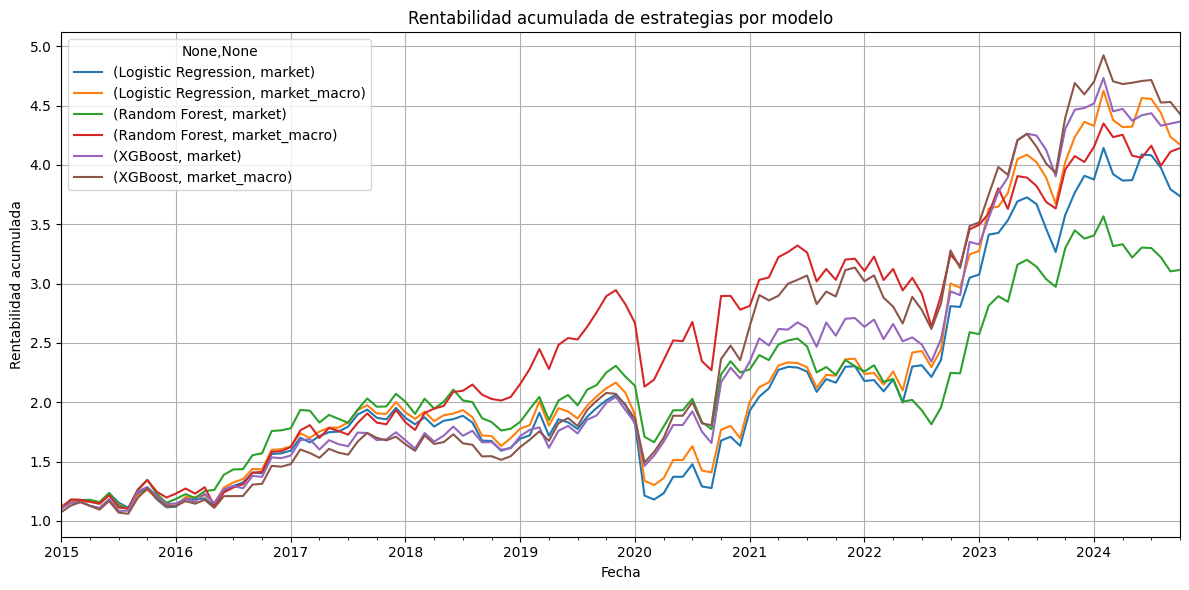

In [9]:
import matplotlib.pyplot as plt

ax = cumulative_df.plot(figsize=(12, 6))

ax.set_title("Rentabilidad acumulada de estrategias por modelo")
ax.set_xlabel("Fecha")
ax.set_ylabel("Rentabilidad acumulada")
ax.grid(True)

plt.tight_layout()
plt.savefig("../results/portfolio/cumulative_returns.png")
plt.show()